# Heart Disease Prediction System

## Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis, preprocessing, and model development for the Heart Disease Prediction System.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_excel("../dataset/Heart_Failure_Prediction_Dataset.xlsx",
                   sheet_name="Dataset",
                   header=3,
                   skiprows=0)


print("Dataset loaded successfully!")

c:\Users\FEMI\Desktop\HeartDiseasePrediction\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\FEMI\Desktop\HeartDiseasePrediction\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Dataset loaded successfully!


In [3]:
# Display the first five rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [9]:
# Statistical summary of numerical variables
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

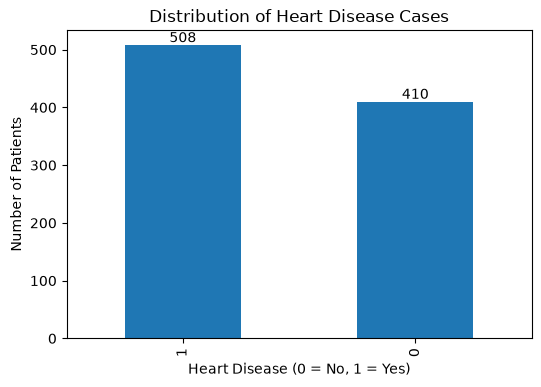

In [11]:
import matplotlib.pyplot as plt

# Count the target classes
heart_counts = df["HeartDisease"].value_counts()

# Create the figure
plt.figure(figsize=(6, 4))

# Plot the chart
heart_counts.plot(kind="bar")

# Add labels and title
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

# Add values on top of each bar
for index, value in enumerate(heart_counts):
    plt.text(index, value + 5, str(value), ha='center')

plt.show()

In [12]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

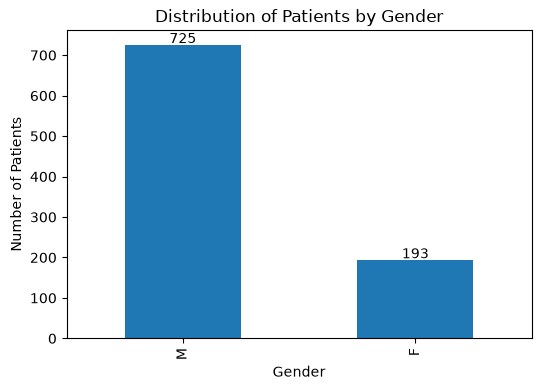

In [13]:
import matplotlib.pyplot as plt

sex_counts = df["Sex"].value_counts()

plt.figure(figsize=(6,4))

sex_counts.plot(kind="bar")

plt.title("Distribution of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

# Display values on top of bars
for index, value in enumerate(sex_counts):
    plt.text(index, value + 5, str(value), ha='center')

plt.show()

In [14]:
df["Age"].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

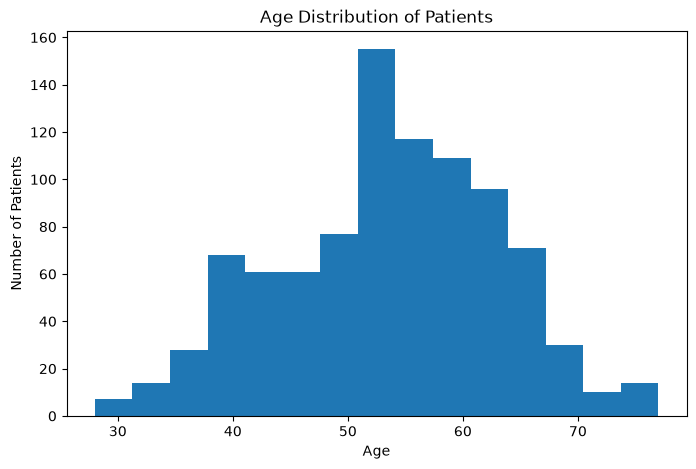

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


In [16]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

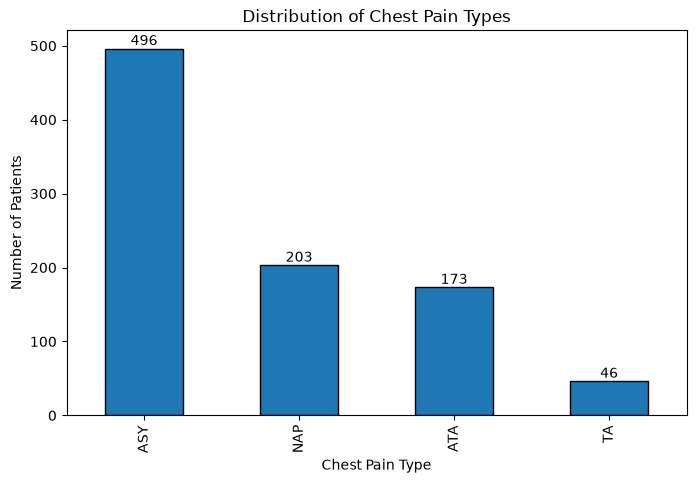

In [17]:
chest_counts = df["ChestPainType"].value_counts()

plt.figure(figsize=(8,5))

chest_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

for index, value in enumerate(chest_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [18]:
df["RestingBP"].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

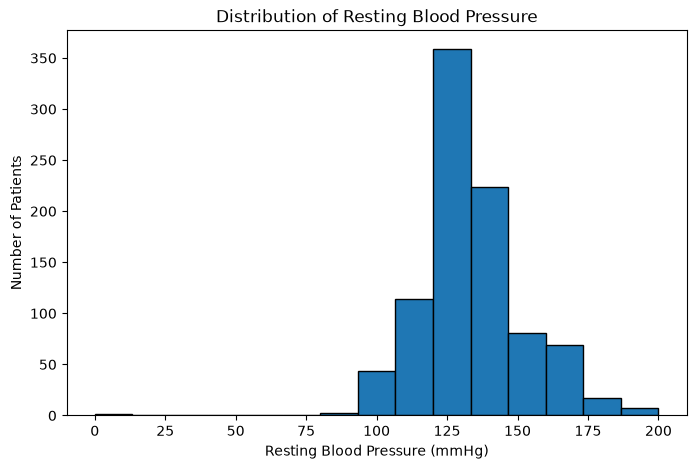

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["RestingBP"], bins=15, edgecolor="black")

plt.title("Distribution of Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_3584\2352482158.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["RestingBP"], vert=False)


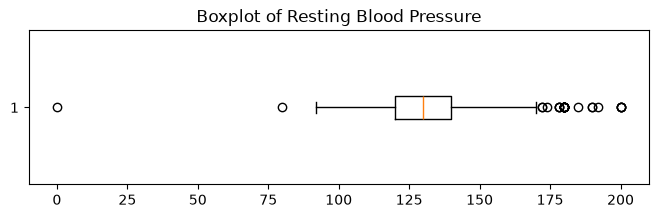

In [20]:
plt.figure(figsize=(8,2))

plt.boxplot(df["RestingBP"], vert=False)

plt.title("Boxplot of Resting Blood Pressure")

plt.show()

In [21]:
df["Cholesterol"].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

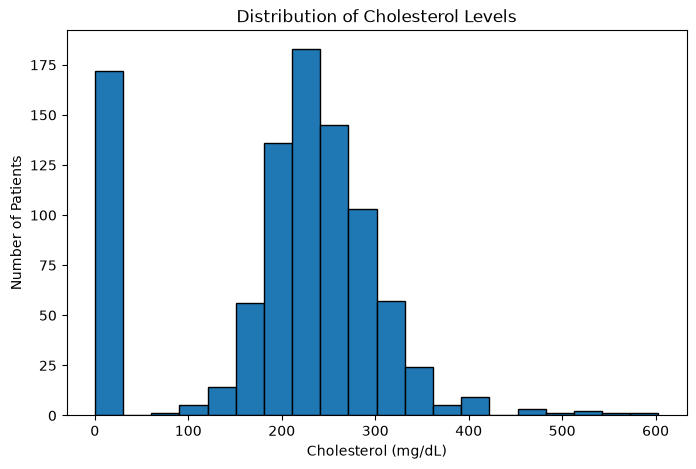

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Cholesterol"], bins=20, edgecolor="black")

plt.title("Distribution of Cholesterol Levels")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_3584\62348449.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Cholesterol"], vert=False)


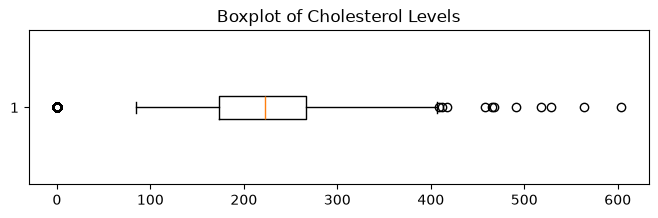

In [23]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Cholesterol"], vert=False)

plt.title("Boxplot of Cholesterol Levels")

plt.show()

In [24]:
df["MaxHR"].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

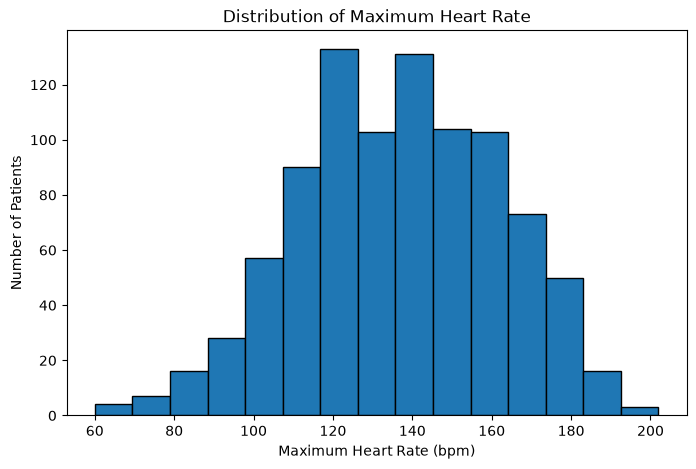

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df["MaxHR"], bins=15, edgecolor="black")

plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Number of Patients")

plt.show()

C:\Users\FEMI\AppData\Local\Temp\ipykernel_3584\1018275559.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["MaxHR"], vert=False)


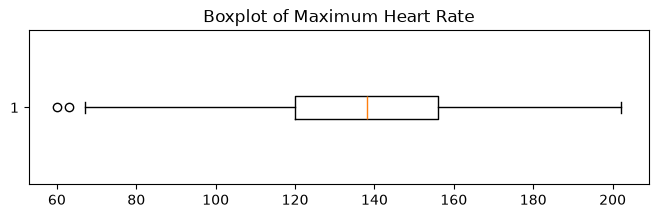

In [26]:
plt.figure(figsize=(8,2))

plt.boxplot(df["MaxHR"], vert=False)

plt.title("Boxplot of Maximum Heart Rate")

plt.show()

In [27]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

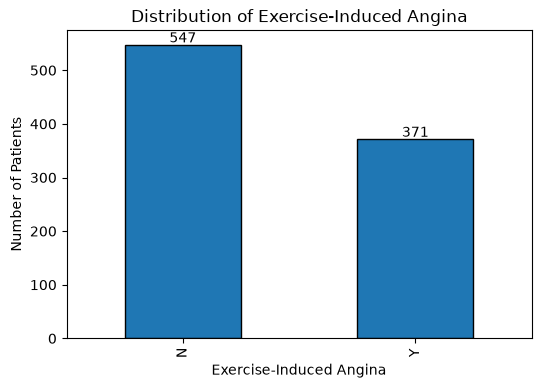

In [28]:
exercise_counts = df["ExerciseAngina"].value_counts()

plt.figure(figsize=(6,4))

exercise_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

for index, value in enumerate(exercise_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [29]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

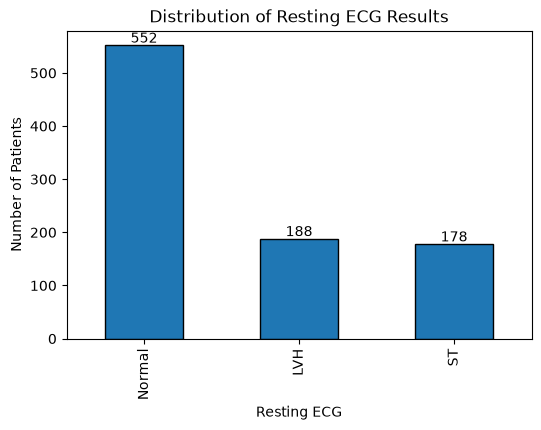

In [30]:
ecg_counts = df["RestingECG"].value_counts()

plt.figure(figsize=(6,4))

ecg_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Resting ECG Results")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")

for index, value in enumerate(ecg_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [31]:
df["FastingBS"].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

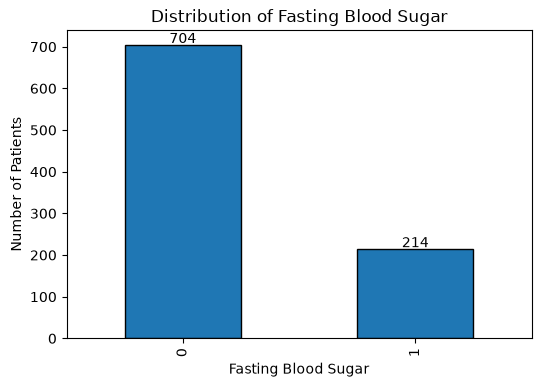

In [32]:
fasting_counts = df["FastingBS"].value_counts()

plt.figure(figsize=(6,4))

fasting_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")

for index, value in enumerate(fasting_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [33]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

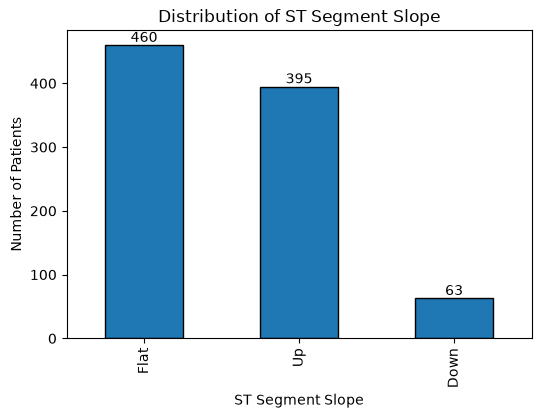

In [34]:
st_counts = df["ST_Slope"].value_counts()

plt.figure(figsize=(6,4))

st_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of ST Segment Slope")
plt.xlabel("ST Segment Slope")
plt.ylabel("Number of Patients")

for index, value in enumerate(st_counts):
    plt.text(index, value + 5, str(value), ha="center")

plt.show()

In [35]:
pd.crosstab(df["Sex"], df["HeartDisease"])

HeartDisease,0,1
Sex,,
F,143,50
M,267,458


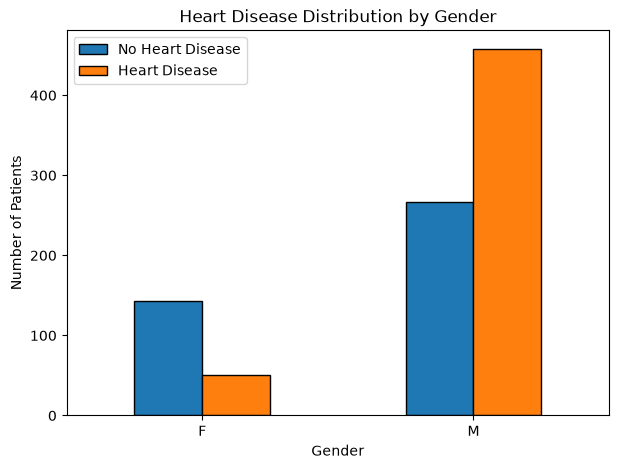

In [36]:
gender_hd = pd.crosstab(df["Sex"], df["HeartDisease"])

gender_hd.plot(kind="bar", figsize=(7,5), edgecolor="black")

plt.title("Heart Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

plt.show()

In [37]:
pd.crosstab(df["ChestPainType"], df["HeartDisease"])

HeartDisease,0,1
ChestPainType,,
ASY,104,392
ATA,149,24
NAP,131,72
TA,26,20


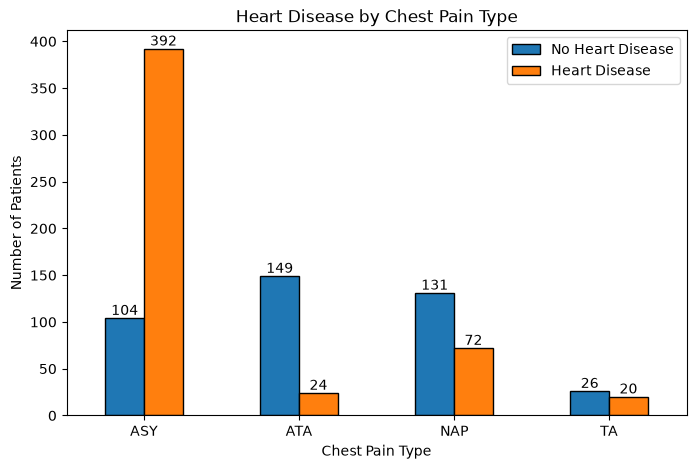

In [38]:
cp_hd = pd.crosstab(df["ChestPainType"], df["HeartDisease"])

ax = cp_hd.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

# Display values on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [39]:
pd.crosstab(df["ExerciseAngina"], df["HeartDisease"])

HeartDisease,0,1
ExerciseAngina,,
N,355,192
Y,55,316


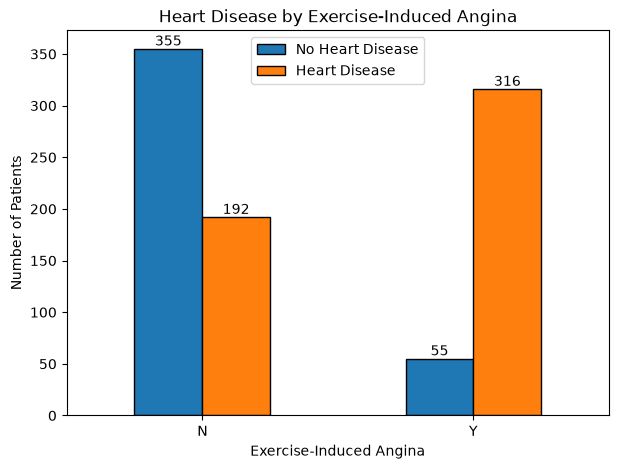

In [40]:
exercise_hd = pd.crosstab(df["ExerciseAngina"], df["HeartDisease"])

ax = exercise_hd.plot(
    kind="bar",
    figsize=(7,5),
    edgecolor="black"
)

plt.title("Heart Disease by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [41]:
pd.crosstab(df["RestingECG"], df["HeartDisease"])

HeartDisease,0,1
RestingECG,,
LVH,82,106
Normal,267,285
ST,61,117


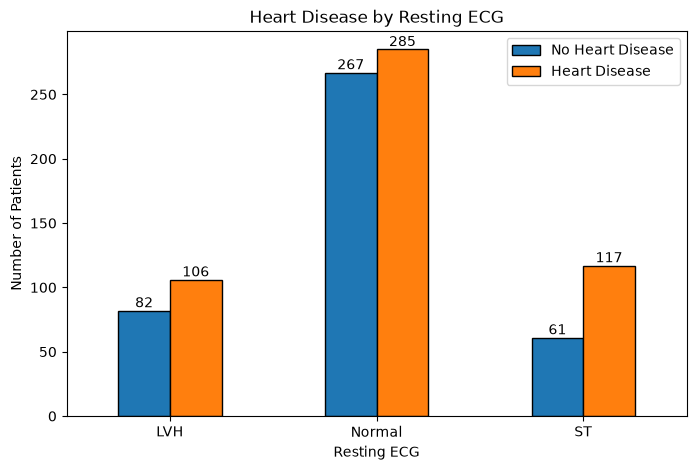

In [42]:
ecg_hd = pd.crosstab(df["RestingECG"], df["HeartDisease"])

ax = ecg_hd.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Heart Disease by Resting ECG")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [43]:
pd.crosstab(df["FastingBS"], df["HeartDisease"])

HeartDisease,0,1
FastingBS,,
0,366,338
1,44,170


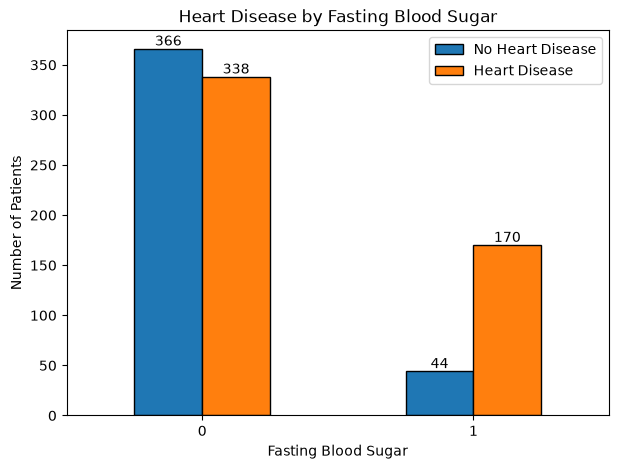

In [44]:
fasting_hd = pd.crosstab(df["FastingBS"], df["HeartDisease"])

ax = fasting_hd.plot(
    kind="bar",
    figsize=(7,5),
    edgecolor="black"
)

plt.title("Heart Disease by Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [45]:
pd.crosstab(df["ST_Slope"], df["HeartDisease"])

HeartDisease,0,1
ST_Slope,,
Down,14,49
Flat,79,381
Up,317,78


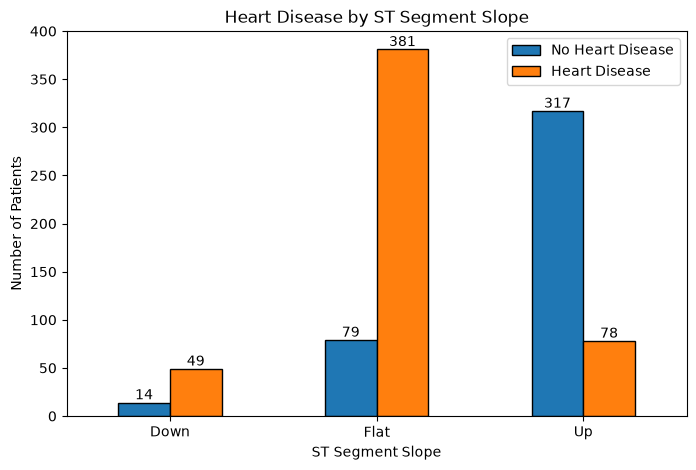

In [46]:
st_hd = pd.crosstab(df["ST_Slope"], df["HeartDisease"])

ax = st_hd.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Heart Disease by ST Segment Slope")
plt.xlabel("ST Segment Slope")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

<Figure size 800x500 with 0 Axes>

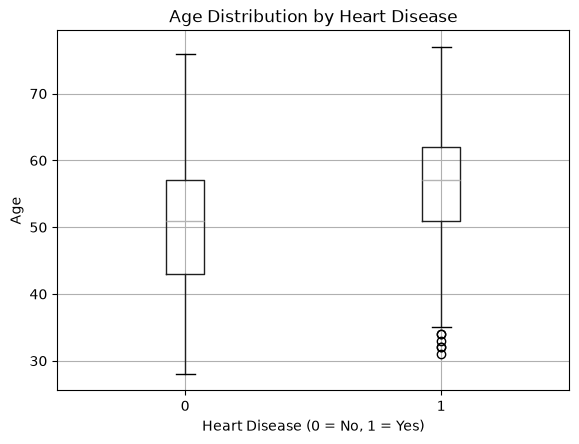

In [47]:
plt.figure(figsize=(8,5))

df.boxplot(column="Age", by="HeartDisease")

plt.title("Age Distribution by Heart Disease")
plt.suptitle("")  # Removes the automatic subtitle
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

In [48]:
df.groupby("HeartDisease")["Age"].describe()


,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,50.551220,9.444915,28.0,43.0,51.0,57.0,76.0
1,508.0,55.899606,8.727056,31.0,51.0,57.0,62.0,77.0


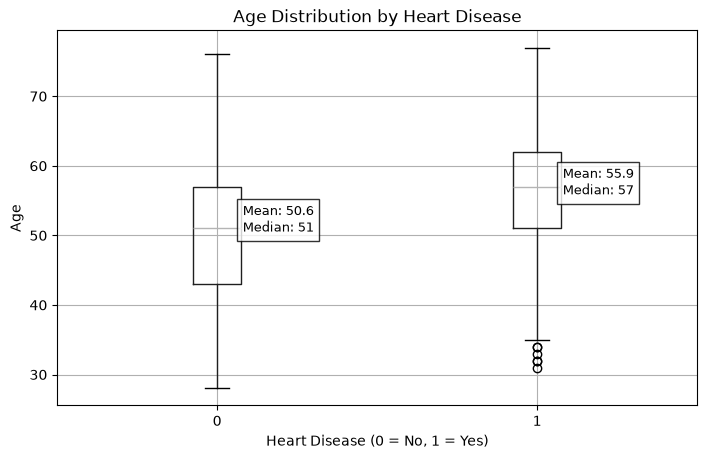

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

df.boxplot(column="Age", by="HeartDisease", ax=ax)

plt.title("Age Distribution by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

# Summary statistics
stats = df.groupby("HeartDisease")["Age"].describe()

# Add mean labels
for i, group in enumerate(stats.index, start=1):
    mean = stats.loc[group, "mean"]
    median = stats.loc[group, "50%"]

    ax.text(
        i + 0.08,
        mean,
        f"Mean: {mean:.1f}\nMedian: {median:.0f}",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8)
    )

plt.show()

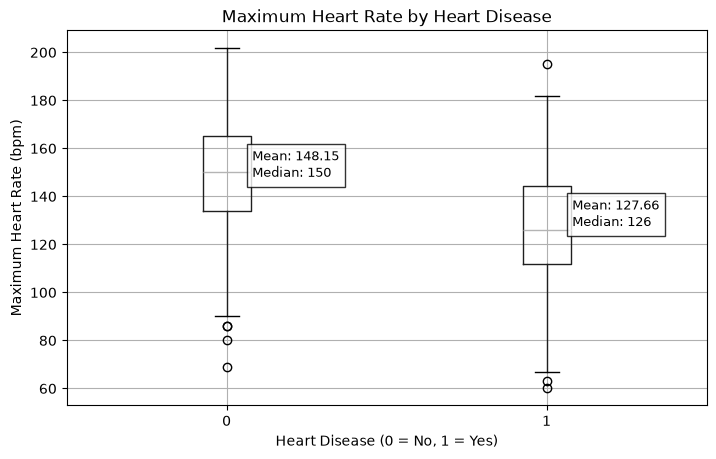

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

df.boxplot(column="MaxHR", by="HeartDisease", ax=ax)

plt.title("Maximum Heart Rate by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate (bpm)")

# Calculate statistics
stats = df.groupby("HeartDisease")["MaxHR"].describe()

# Add Mean and Median labels
for i, group in enumerate(stats.index, start=1):
    mean = stats.loc[group, "mean"]
    median = stats.loc[group, "50%"]

    ax.text(
        i + 0.08,
        mean,
        f"Mean: {mean:.2f}\nMedian: {median:.0f}",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
    )

plt.show()

In [51]:
df.groupby("HeartDisease")["MaxHR"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,148.151220,23.288067,69.0,134.0,150.0,165.00,202.0
1,508.0,127.655512,23.386923,60.0,112.0,126.0,144.25,195.0


<Figure size 800x500 with 0 Axes>

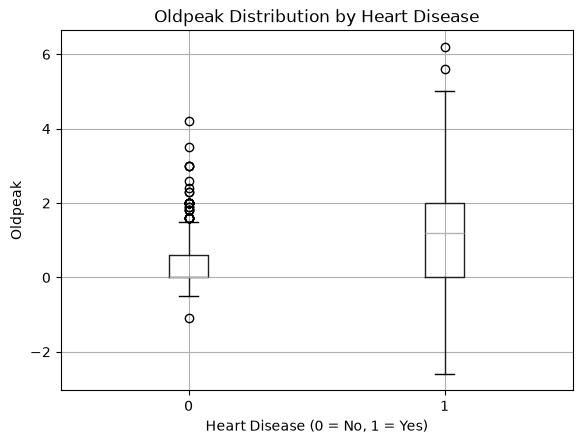

In [52]:
plt.figure(figsize=(8,5))

df.boxplot(column="Oldpeak", by="HeartDisease")

plt.title("Oldpeak Distribution by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Oldpeak")

plt.show()

In [53]:
df.groupby("HeartDisease")["Oldpeak"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,0.408049,0.699709,-1.1,0.0,0.0,0.6,4.2
1,508.0,1.274213,1.151872,-2.6,0.0,1.2,2.0,6.2


In [54]:
(df["RestingBP"] == 0).sum()

np.int64(1)

In [55]:
# Calculate median values excluding invalid entries
median_bp = df.loc[df["RestingBP"] != 0, "RestingBP"].median()
median_chol = df.loc[df["Cholesterol"] != 0, "Cholesterol"].median()

# Replace invalid values
df.loc[df["RestingBP"] == 0, "RestingBP"] = median_bp
df.loc[df["Cholesterol"] == 0, "Cholesterol"] = median_chol

print("Invalid values replaced successfully!")

Invalid values replaced successfully!


In [56]:
print("RestingBP =", (df["RestingBP"] == 0).sum())
print("Cholesterol =", (df["Cholesterol"] == 0).sum())

RestingBP = 0
Cholesterol = 0


In [57]:
df_encoded = df.copy()

In [79]:
from sklearn.preprocessing import LabelEncoder

In [80]:
label_encoders = {}

categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


In [81]:
import joblib
joblib.dump(label_encoders, '../model/label_encoders.pkl')

['../model/label_encoders.pkl']

In [82]:
df_encoded.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [83]:
df_encoded.dtypes

Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG          int64
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
ST_Slope            int64
HeartDisease        int64
dtype: object

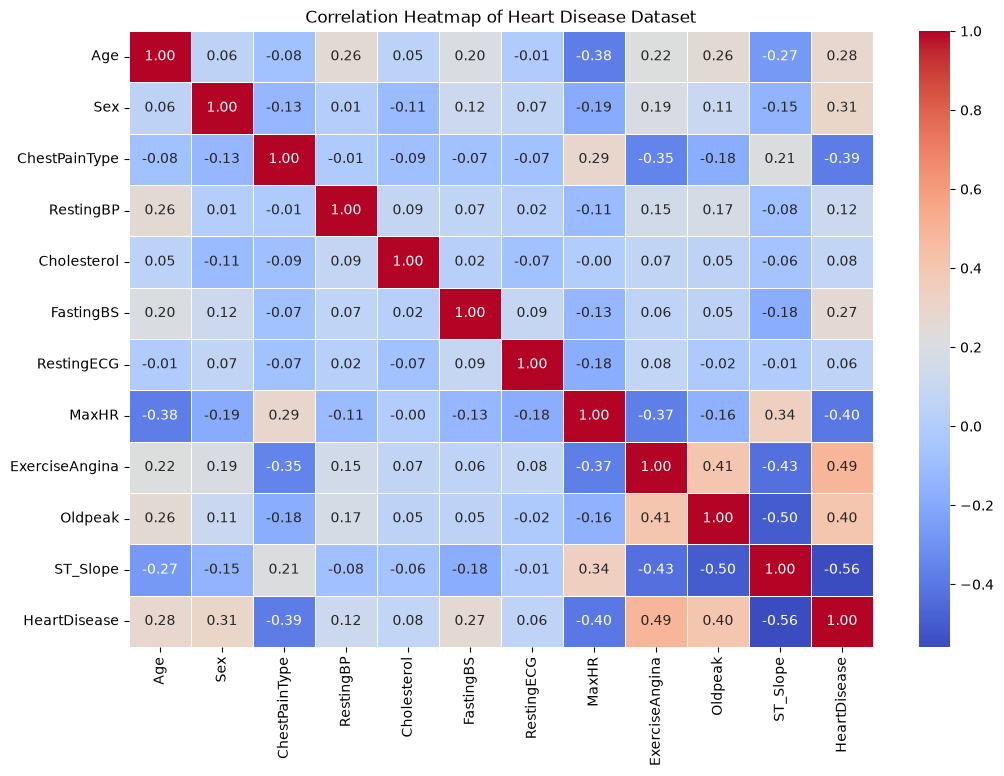

In [84]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.show()

In [85]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (734, 11)
Testing set: (184, 11)


In [86]:
from sklearn.linear_model import LogisticRegression

In [87]:
# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [88]:
# Predict heart disease on the testing dataset
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 1 1 0 1 1 0 1 1]


In [89]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 84.24%


In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [91]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

Accuracy: 0.842
Precision: 0.906
Recall: 0.813
F1-Score: 0.857


In [92]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68  9]
 [20 87]]


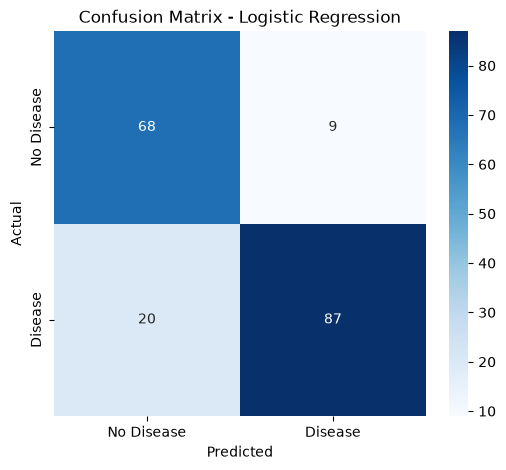

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [94]:
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.77      0.88      0.82        77
     Disease       0.91      0.81      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



In [95]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print(coefficients)

           Feature  Coefficient  Abs_Coefficient
10        ST_Slope    -1.630932         1.630932
1              Sex     1.296332         1.296332
8   ExerciseAngina     1.126125         1.126125
5        FastingBS     1.080730         1.080730
2    ChestPainType    -0.583535         0.583535
9          Oldpeak     0.424051         0.424051
6       RestingECG    -0.123900         0.123900
0              Age     0.015951         0.015951
7            MaxHR    -0.012382         0.012382
3        RestingBP     0.003176         0.003176
4      Cholesterol     0.000456         0.000456


In [96]:
import joblib
joblib.dump(model, '../model/heart_disease_model.pkl')

['../model/heart_disease_model.pkl']

In [97]:
import os
print(os.path.exists('../model/heart_disease_model.pkl'))
print(os.path.getsize('../model/heart_disease_model.pkl'), "bytes")

True
1327 bytes


In [98]:
loaded_model = joblib.load('../model/heart_disease_model.pkl')
print(loaded_model.predict(X_test[:5]))

[0 0 1 1 0]


In [99]:
import os
print(os.path.exists('../model/label_encoders.pkl'))

True
